In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [11]:
columns = ['age', 'sex', 'cp', 'trestbps', 'cholesterol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

data = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')
data['cholesterol'] = pd.to_numeric(data['cholesterol'], errors='coerce')

print("Total patients:", len(data))
print("Missing values:\n", data.isnull().sum())

# drop remaining missing values for modeling
model_data = data.dropna()
print("Patients after cleaning:", len(model_data))

Total patients: 303
Missing values:
 age            0
sex            0
cp             0
trestbps       0
cholesterol    0
fbs            0
restecg        0
thalach        0
exang          0
oldpeak        0
slope          0
ca             4
thal           2
target         0
dtype: int64
Patients after cleaning: 297


In [12]:
#x = model_data[['age', 'cholesterol', 'thalach', 'trestbps']]
x = model_data.drop(columns=['target']) # all features except target
y = (model_data['target'] > 0).astype(int) # binary: disease or not

print("Total patients:", len(model_data))
print(y.value_counts())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Total patients: 297
target
0    160
1    137
Name: count, dtype: int64


In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
predictions = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.8833333333333333


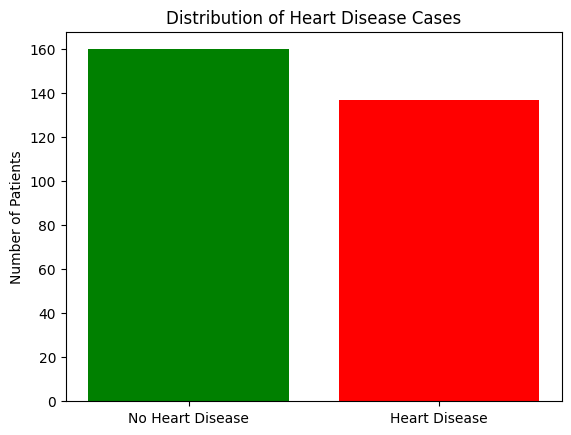

In [15]:
labels = ['No Heart Disease', 'Heart Disease']
counts = y.value_counts().sort_index()
plt.bar(labels, counts, color=['green', 'red'])
plt.title('Distribution of Heart Disease Cases')
plt.ylabel('Number of Patients')
plt.show()

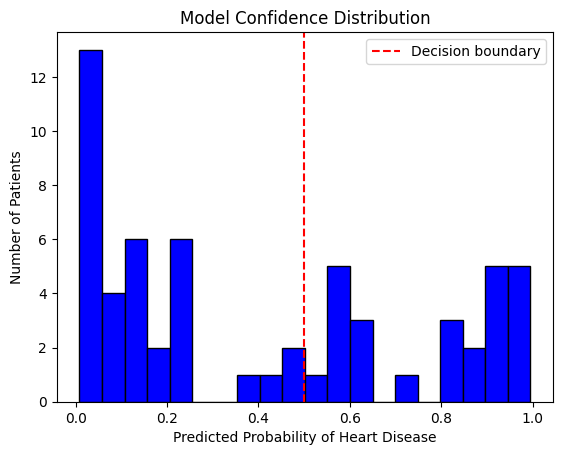

In [16]:
probabilities = model.predict_proba(x_test)[:, 1]

plt.hist(probabilities, bins=20, color='blue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Decision boundary')
plt.xlabel('Predicted Probability of Heart Disease')
plt.ylabel('Number of Patients')
plt.title('Model Confidence Distribution')
plt.legend()
plt.show()

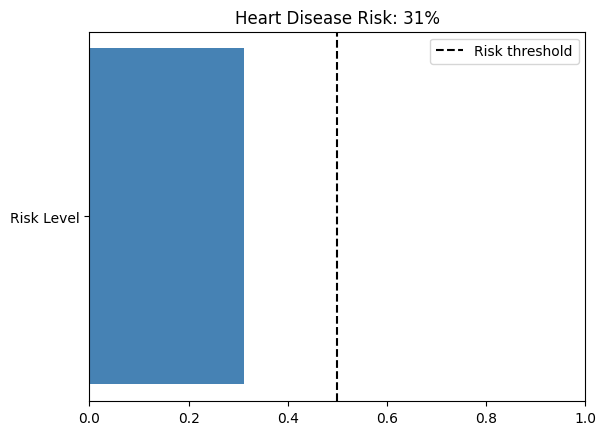

In [17]:
new_patient = pd.DataFrame([[52, 1, 4, 130, 240, 0, 0, 150, 0, 1.5, 2, 0, 3]], 
                            columns=model_data.drop(columns=['target']).columns)

probability = model.predict_proba(new_patient)[0][1]

plt.barh(['Risk Level'], [probability], color='tomato' if probability > 0.5 else 'steelblue')
plt.axvline(0.5, color='black', linestyle='--', label='Risk threshold')
plt.xlim(0, 1)
plt.title(f'Heart Disease Risk: {probability:.0%}')
plt.legend()
plt.show()

In [18]:
new_patient = pd.DataFrame([[52, 1, 4, 130, 240, 0, 0, 150, 0, 1.5, 2, 0, 3]], 
                            columns=model_data.drop(columns=['target']).columns)

prediction = model.predict(new_patient)
print("Heart Disease:", "Yes" if prediction[0] == 1 else "No")

Heart Disease: No
